# Doctorado en Ciencia de la Computación
## Minería de Datos
### Catedrático: Dr. Ivar Vargas Belizario
#### Trabajo Encargado 1: Shelter Animal Outcomes
##### Integrantes:
##### - Israel N. Chaparro-Cruz
##### - Roger Ramos Serruto
##### - Christian Rolando Rodriguez Tupayachi
##### - Ester Carolina Mendoza Yaresi

# 0. Importando librerías, Cargando Datos

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
sns.set(style="whitegrid")

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# 1.1 Pre-procesamiento

Verificaremos cuantos valores nulos tenemos y cuál es el tipo de dato de cada uno de los atributos o características:

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26729 entries, 0 to 26728
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   AnimalID        26729 non-null  object
 1   Name            19038 non-null  object
 2   DateTime        26729 non-null  object
 3   OutcomeType     26729 non-null  object
 4   OutcomeSubtype  13117 non-null  object
 5   AnimalType      26729 non-null  object
 6   SexuponOutcome  26728 non-null  object
 7   AgeuponOutcome  26711 non-null  object
 8   Breed           26729 non-null  object
 9   Color           26729 non-null  object
dtypes: object(10)
memory usage: 2.0+ MB


Podemos ver que tenemos muchos valores faltantes en Name y Outcomesubtype y algunos pocos en AgreuponOutcome y SexuoponOutcome.
1. Outcomesubtype es una característica objetivo que no se usará y no es requerido en el reto de Kaggle.
2. SexuponOutcome y AgeuponOutcome tiene muy pocos valores faltantes, por lo que aplicaremos imputación de datos.

Ahora examinaremos cada una de las características:

In [4]:
train.describe()

,AnimalID,Name,DateTime,OutcomeType,OutcomeSubtype,AnimalType,SexuponOutcome,AgeuponOutcome,Breed,Color
count,26729,19038,26729,26729,13117,26729,26728,26711,26729,26729
unique,26729,6374,22918,5,16,2,5,44,1380,366
top,A706629,Max,2015-08-11 00:00:00,Adoption,Partner,Dog,Neutered Male,1 year,Domestic Shorthair Mix,Black/White
freq,1,136,19,10769,7816,15595,9779,3969,8810,2824


Podemos ver que los únicos que tienen pocos valores son:
* OutcomeType
* AnimalType
* SexuponOutcome
* AgeuponOutcome
Por lo tanto solo mostraremos gráficas de ellos



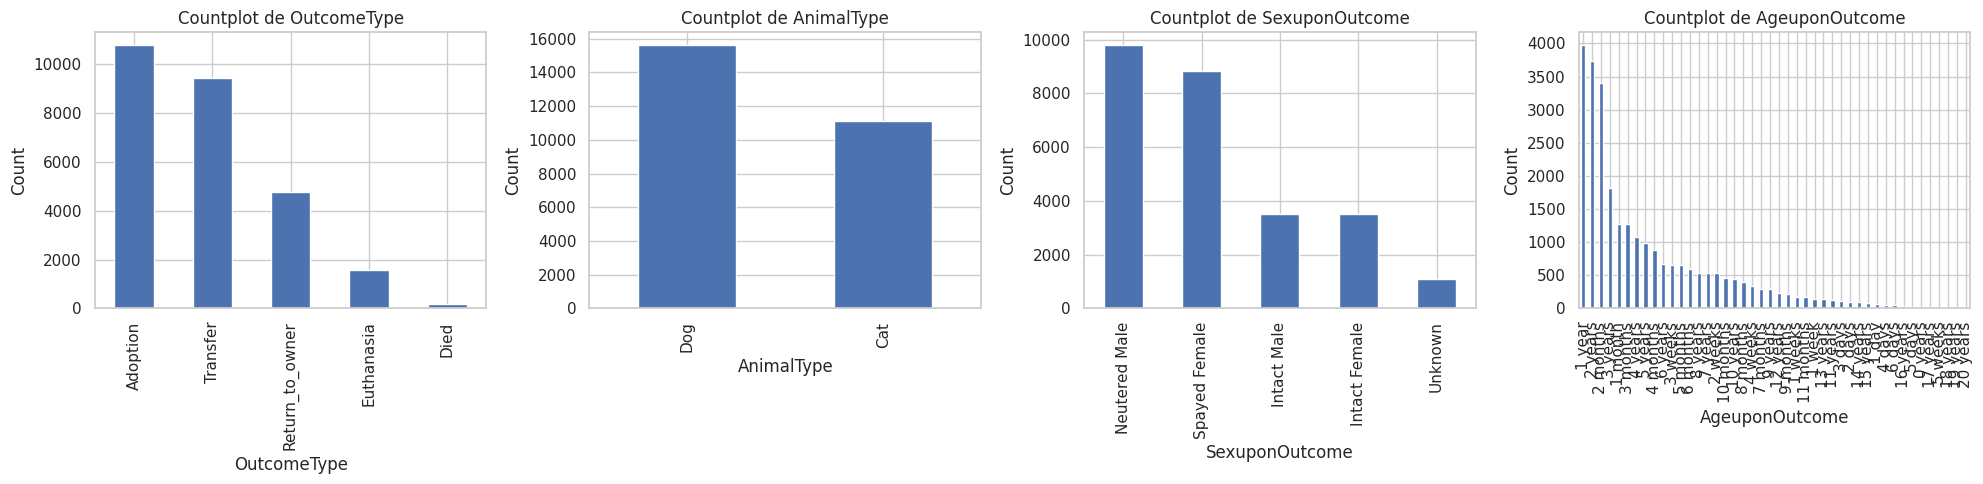

In [5]:
columnas_a_graficar = [
    'OutcomeType',
    'AnimalType',
    'SexuponOutcome',
    'AgeuponOutcome',
]

fig, axes = plt.subplots(1, len(columnas_a_graficar), figsize=(5 * len(columnas_a_graficar), 5))

for i, col in enumerate(columnas_a_graficar):
    train[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Countplot de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# 1.2 Transformación de datos

**DateTime**: convertirmos la fecha a minuto hora, dia de la semana, dia del mes y año.

In [6]:
for df in [train, test]:
    df['fecha'] = pd.to_datetime(df['DateTime'])
    df['Hour'] = df['fecha'].dt.hour
    df['Minute'] = df['fecha'].dt.minute
    df['DayofWeek'] = df['fecha'].dt.dayofweek
    df['Day'] = df['fecha'].dt.day
    df['Month'] = df['fecha'].dt.month
    df['Year'] = df['fecha'].dt.year

**AgeuponOutcome**: convertimos a días y rellenamos los faltantes con la mediana.

In [7]:
def age_to_days(age):
    if pd.isnull(age):
        return np.nan
    num, unit = age.split()
    num = int(num)
    if 'day' in unit:
        return num
    elif 'week' in unit:
        return num * 7
    elif 'month' in unit:
        return num * 30
    elif 'year' in unit:
        return num * 365
    return np.nan

In [8]:
for df in [train, test]:
    df['AgeDays'] = df['AgeuponOutcome'].apply(age_to_days)

In [9]:
mediana = train['AgeDays'].median()
train['AgeDays'].fillna(mediana, inplace=True)
test['AgeDays'].fillna(mediana, inplace=True)

<ipython-input-9-e4da2a43b6c1>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['AgeDays'].fillna(mediana, inplace=True)
<ipython-input-9-e4da2a43b6c1>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

**SexuponOutcome**: rellenamos faltantes con el valor 'Unknow' (que ya existe en los datos).

In [10]:
for df in [train, test]:
    df['SexuponOutcome'].fillna('Unknown', inplace=True)

<ipython-input-10-8b8b6cd45d84>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['SexuponOutcome'].fillna('Unknown', inplace=True)


**Breed**: extraemos la raza primaria y flag de mezcla.

In [11]:
for df in [train, test]:
    df['BreedPrimary'] = df['Breed'].apply(lambda x: x.split('/')[0].replace(' Mix',''))
    df['IsMix'] = df['Breed'].str.contains('Mix').astype(int)

**Color**: extraemos el color primario.

In [12]:
for df in [train, test]:
    df['ColorPrimary'] = df['Color'].apply(lambda x: x.split('/')[0])

**Name**: creamos unflag si tiene nombre.

In [13]:
for df in [train, test]:
    df['HasName'] = df['Name'].notnull().astype(int)

Imprimimos las columnas finales

In [14]:
df.columns

Index(['ID', 'Name', 'DateTime', 'AnimalType', 'SexuponOutcome',
       'AgeuponOutcome', 'Breed', 'Color', 'fecha', 'Hour', 'Minute',
       'DayofWeek', 'Day', 'Month', 'Year', 'AgeDays', 'BreedPrimary', 'IsMix',
       'ColorPrimary', 'HasName'],
      dtype='object')

Usaremos solamente las siguientes características:

In [15]:
features = [
    'AnimalType',
    'SexuponOutcome',
    'Hour',
    'Minute',
    'DayofWeek',
    'Day',
    'Month',
    'Year',
    'AgeDays',
    'BreedPrimary',
    'IsMix',
    'ColorPrimary',
    'HasName'
]

Verificaremos que características requieren codificación especial.

In [16]:
df[features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11456 entries, 0 to 11455
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   AnimalType      11456 non-null  object 
 1   SexuponOutcome  11456 non-null  object 
 2   Hour            11456 non-null  int32  
 3   Minute          11456 non-null  int32  
 4   DayofWeek       11456 non-null  int32  
 5   Day             11456 non-null  int32  
 6   Month           11456 non-null  int32  
 7   Year            11456 non-null  int32  
 8   AgeDays         11456 non-null  float64
 9   BreedPrimary    11456 non-null  object 
 10  IsMix           11456 non-null  int64  
 11  ColorPrimary    11456 non-null  object 
 12  HasName         11456 non-null  int64  
dtypes: float64(1), int32(6), int64(2), object(4)
memory usage: 895.1+ KB


Por lo visto, AnimalType, SexuponOutcome, BreedPrimary y ColorPrimary son los que requieren tratamiento categórico.

In [22]:
encoders = {}
for col in ['AnimalType','SexuponOutcome','BreedPrimary','ColorPrimary']:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]], axis=0).astype(str))
    train[col] = le.transform(train[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))
    encoders[col] = le

In [23]:
le_target = LabelEncoder()
y = le_target.fit_transform(train[['OutcomeType']])

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [24]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26729 entries, 0 to 26728
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   AnimalID        26729 non-null  object        
 1   Name            19038 non-null  object        
 2   DateTime        26729 non-null  object        
 3   OutcomeType     26729 non-null  object        
 4   OutcomeSubtype  13117 non-null  object        
 5   AnimalType      26729 non-null  int64         
 6   SexuponOutcome  26729 non-null  int64         
 7   AgeuponOutcome  26711 non-null  object        
 8   Breed           26729 non-null  object        
 9   Color           26729 non-null  object        
 10  fecha           26729 non-null  datetime64[ns]
 11  Hour            26729 non-null  int32         
 12  Minute          26729 non-null  int32         
 13  DayofWeek       26729 non-null  int32         
 14  Day             26729 non-null  int32         
 15  Mo

# 2. Dividir el Conjunto de Entrenamiento y Entrenar Modelos

Usaremos el 20% en validación.

In [25]:
X = train[features]
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Entrenando el modelo XGBClassifier

In [31]:
model_xg = XGBClassifier(
    objective='multi:softprob',
    num_class=len(le_target.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)
model_xg.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

[0]	validation_0-mlogloss:1.31323
[1]	validation_0-mlogloss:1.15538
[2]	validation_0-mlogloss:1.05335
[3]	validation_0-mlogloss:0.98111
[4]	validation_0-mlogloss:0.92910
[5]	validation_0-mlogloss:0.89076
[6]	validation_0-mlogloss:0.86349
[7]	validation_0-mlogloss:0.84188
[8]	validation_0-mlogloss:0.82626
[9]	validation_0-mlogloss:0.81430
[10]	validation_0-mlogloss:0.80426
[11]	validation_0-mlogloss:0.79666
[12]	validation_0-mlogloss:0.79060
[13]	validation_0-mlogloss:0.78584
[14]	validation_0-mlogloss:0.78212
[15]	validation_0-mlogloss:0.77806
[16]	validation_0-mlogloss:0.77581


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:43:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[17]	validation_0-mlogloss:0.77454
[18]	validation_0-mlogloss:0.77240
[19]	validation_0-mlogloss:0.77050
[20]	validation_0-mlogloss:0.76910
[21]	validation_0-mlogloss:0.76793
[22]	validation_0-mlogloss:0.76592
[23]	validation_0-mlogloss:0.76468
[24]	validation_0-mlogloss:0.76454
[25]	validation_0-mlogloss:0.76345
[26]	validation_0-mlogloss:0.76304
[27]	validation_0-mlogloss:0.76151
[28]	validation_0-mlogloss:0.76050
[29]	validation_0-mlogloss:0.76001
[30]	validation_0-mlogloss:0.75974
[31]	validation_0-mlogloss:0.75941
[32]	validation_0-mlogloss:0.75979
[33]	validation_0-mlogloss:0.75935
[34]	validation_0-mlogloss:0.75892
[35]	validation_0-mlogloss:0.75935
[36]	validation_0-mlogloss:0.75951
[37]	validation_0-mlogloss:0.75910
[38]	validation_0-mlogloss:0.75934
[39]	validation_0-mlogloss:0.75903
[40]	validation_0-mlogloss:0.75869
[41]	validation_0-mlogloss:0.75796
[42]	validation_0-mlogloss:0.75856
[43]	validation_0-mlogloss:0.75788
[44]	validation_0-mlogloss:0.75758
[45]	validation_0-ml

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=5, num_parallel_tree=None, ...)

Entrenando un Random Forest

In [39]:
model_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

# 3. Validando el modelo con el conjunto de Validación

Validamos el modelo XGBoost con la métrica Accuracy y otras métricas.

In [41]:
y_pred_xg = model_xg.predict(X_val)
print("Accuracy:", accuracy_score(y_val, y_pred_xg))
print("\Report:\n", classification_report(
    y_val, y_pred_xg, target_names=le_target.classes_
))

Accuracy: 0.6909839132061354
\Report:
                  precision    recall  f1-score   support

       Adoption       0.72      0.81      0.77      2154
           Died       1.00      0.03      0.05        39
     Euthanasia       0.62      0.35      0.45       311
Return_to_owner       0.50      0.50      0.50       957
       Transfer       0.76      0.72      0.74      1885

       accuracy                           0.69      5346
      macro avg       0.72      0.48      0.50      5346
   weighted avg       0.69      0.69      0.68      5346



Validamos el modelo RandomForest con la métrica Accuracy y otras métricas.

In [42]:
y_pred_rf = model_rf.predict(X_val)
print("Accuracy:", accuracy_score(y_val, y_pred_rf))
print("\Report:\n", classification_report(
    y_val, y_pred_rf, target_names=le_target.classes_
))

Accuracy: 0.6956603067714179
\Report:
                  precision    recall  f1-score   support

       Adoption       0.71      0.83      0.77      2154
           Died       0.00      0.00      0.00        39
     Euthanasia       0.72      0.24      0.36       311
Return_to_owner       0.51      0.48      0.49       957
       Transfer       0.76      0.74      0.75      1885

       accuracy                           0.70      5346
      macro avg       0.54      0.46      0.47      5346
   weighted avg       0.69      0.70      0.68      5346



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Random Forest mejora ligeramente el accuracy general (+0.005).
Tiene mejor F1 en Transfer, que es una clase con muchos ejemplos (alta frecuencia).
Ambas fallan gravemente en la clase Died, con casi 0 recall en RF y 0.03 en XGB.
Clase Euthanasia tiene F1 bajo en ambos modelos (mejor en XGB).
Desbalance de clases está claramente afectando el rendimiento.

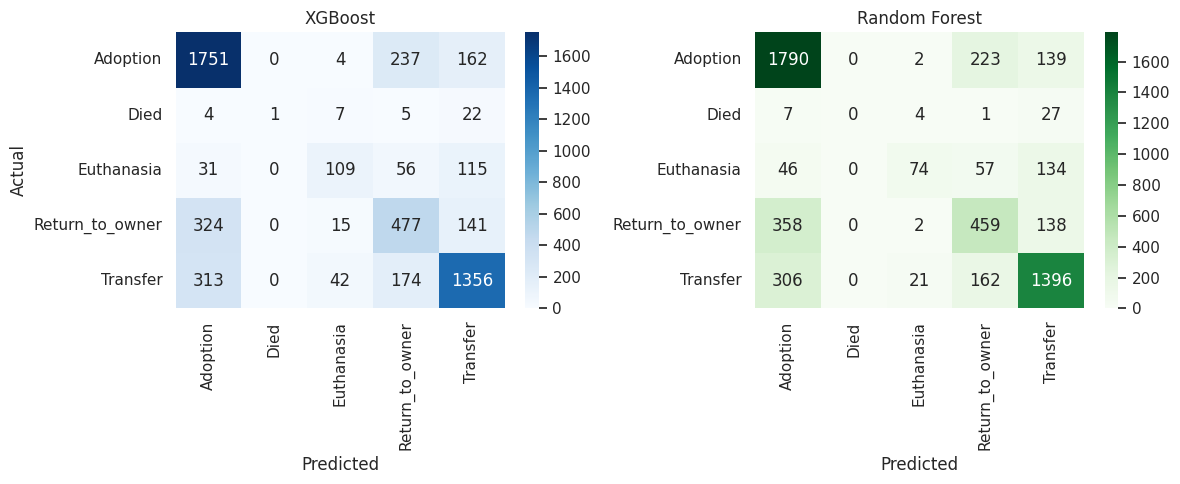

In [44]:
disp_xg = confusion_matrix(y_val, y_pred_xg)
disp_rf = confusion_matrix(y_val, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(disp_xg, annot=True, fmt='d', ax=axes[0],
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            cmap='Blues')
axes[0].set_title('XGBoost')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(disp_rf, annot=True, fmt='d', ax=axes[1],
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            cmap='Greens')
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# 4. Determinar la predicción para el Test

In [45]:
test_probs = model_rf.predict_proba(test[features])

In [47]:
submission = pd.DataFrame(
    test_probs,
    columns=le_target.classes_
)
submission['ID'] = test['ID']
submission = submission[['ID'] + list(le_target.classes_)]

In [48]:
test.columns

Index(['ID', 'Name', 'DateTime', 'AnimalType', 'SexuponOutcome',
       'AgeuponOutcome', 'Breed', 'Color', 'fecha', 'Hour', 'Minute',
       'DayofWeek', 'Day', 'Month', 'Year', 'AgeDays', 'BreedPrimary', 'IsMix',
       'ColorPrimary', 'HasName'],
      dtype='object')

In [49]:
submission.head()

,ID,Adoption,Died,Euthanasia,Return_to_owner,Transfer
0,1,0.015,0.000,0.065,0.260,0.660
1,2,0.570,0.005,0.010,0.345,0.070
2,3,0.275,0.000,0.010,0.150,0.565
3,4,0.160,0.000,0.035,0.205,0.600
4,5,0.585,0.000,0.010,0.375,0.030


In [50]:
submission.to_csv('submission.csv', index=False)

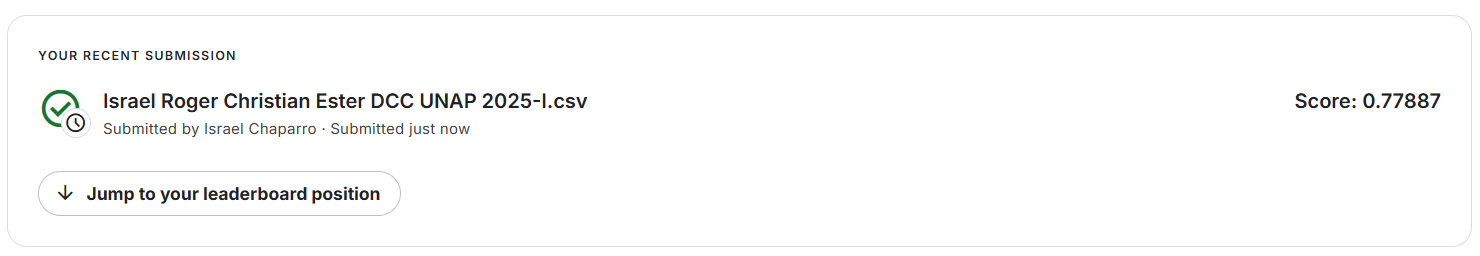